In [1]:
%matplotlib inline
%reset -f

import os, random, time, sys
from timeit import default_timer as timer
from datetime import timedelta
from datetime import datetime

import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy import signal
import pandas as pd
from tqdm import tqdm
import bct
import networkx as nx

import neurogym as ngym
import torch
import torch.nn as nn

from src.neural_network import RNN, run_testing
from src.utils import normalize_x, map_kernel_to_epochs, build_reg_ken, compute_rlfp, get_weight_masks, crofts_communicability, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='DejaVu Sans')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

In [2]:
# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [3]:
save_figs = True

In [4]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model_new'
outdir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'
dt = 100
batch_size = 128
decision = 500
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 2
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 200
n_runs = 25
n_epochs = 10000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.001
kernel_type = 'static'
kernel_std_frac = 0.1
comet_buffer_frac = 0.1
comet_tail_frac = 0.25

mask_weights = True

52


In [5]:
if task == 'PerceptualDecisionMaking-v0':
    input_size = 3
    num_classes = 3
elif task == 'MultiSensoryIntegration-v0':
    input_size = 5
    num_classes = 3

timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir,
    'outdir': outdir,

    # data parameters
    'task': task,
    'dt': dt,
    'seq_len': seq_len,
    'batch_size': batch_size,

    # RNN model and training parameters
    'rnn_model': rnn_model,
    'hidden_size': hidden_size,
    'n_runs': n_runs,
    'n_epochs': n_epochs,
    'lr': lr,
    'mask_weights': mask_weights,

    # regularization parameters
    'reg_type': reg_type,
    'reg_weight': reg_weight,
    'kernel_type': kernel_type,
    'kernel_std_frac': kernel_std_frac,
    'comet_buffer_frac': comet_buffer_frac,
    'comet_tail_frac': comet_tail_frac,

    'env_kwargs': env_kwargs
}

file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-52-128-500_model-rnn-tanh-200-25-10000-0.001_wmask-True_reg-l2-0.001-static-0.1


In [6]:
# load data
log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
training_loss = log_args['training_loss']
validation_loss = log_args['validation_loss']
test_accuracy = log_args['test_accuracy']
n_logged_epochs = test_accuracy.shape[-1]
x_step = int(n_epochs / (n_logged_epochs-1))

checkpoint = torch.load(os.path.join(modeldir, file_str + '.pt'), map_location=device)
hidden_weights = np.zeros((n_runs, n_logged_epochs, hidden_size, hidden_size))
for i, run in enumerate(checkpoint.keys()):
    for j, epoch in enumerate(checkpoint[run].keys()):
        hidden_weights[i, j] = checkpoint[run][epoch]['rnn.weight_hh_l0']

print(training_loss.shape)
print(validation_loss.shape)
print(test_accuracy.shape)
print(hidden_weights.shape)
print(n_logged_epochs)

(25, 10000)
(25, 10000)
(25, 101)
(25, 101, 200, 200)
101


In [7]:
frac = 0.33
masks = get_weight_masks(hidden_size=hidden_size, frac=frac)

In [8]:
# # retain first 5k epochs
# n_epochs = 5000
# n_logged_epochs = 51
# training_loss = training_loss[:, :n_epochs]
# validation_loss = validation_loss[:, :n_epochs]
# test_accuracy = test_accuracy[:, :n_logged_epochs]
# hidden_weights = hidden_weights[:, :n_logged_epochs]
# x_step = int(n_epochs / (n_logged_epochs-1))
#
# print(training_loss.shape)
# print(validation_loss.shape)
# print(test_accuracy.shape)
# print(hidden_weights.shape)
# print(n_logged_epochs)

### Weights

[  0  20  40  60  80 100]


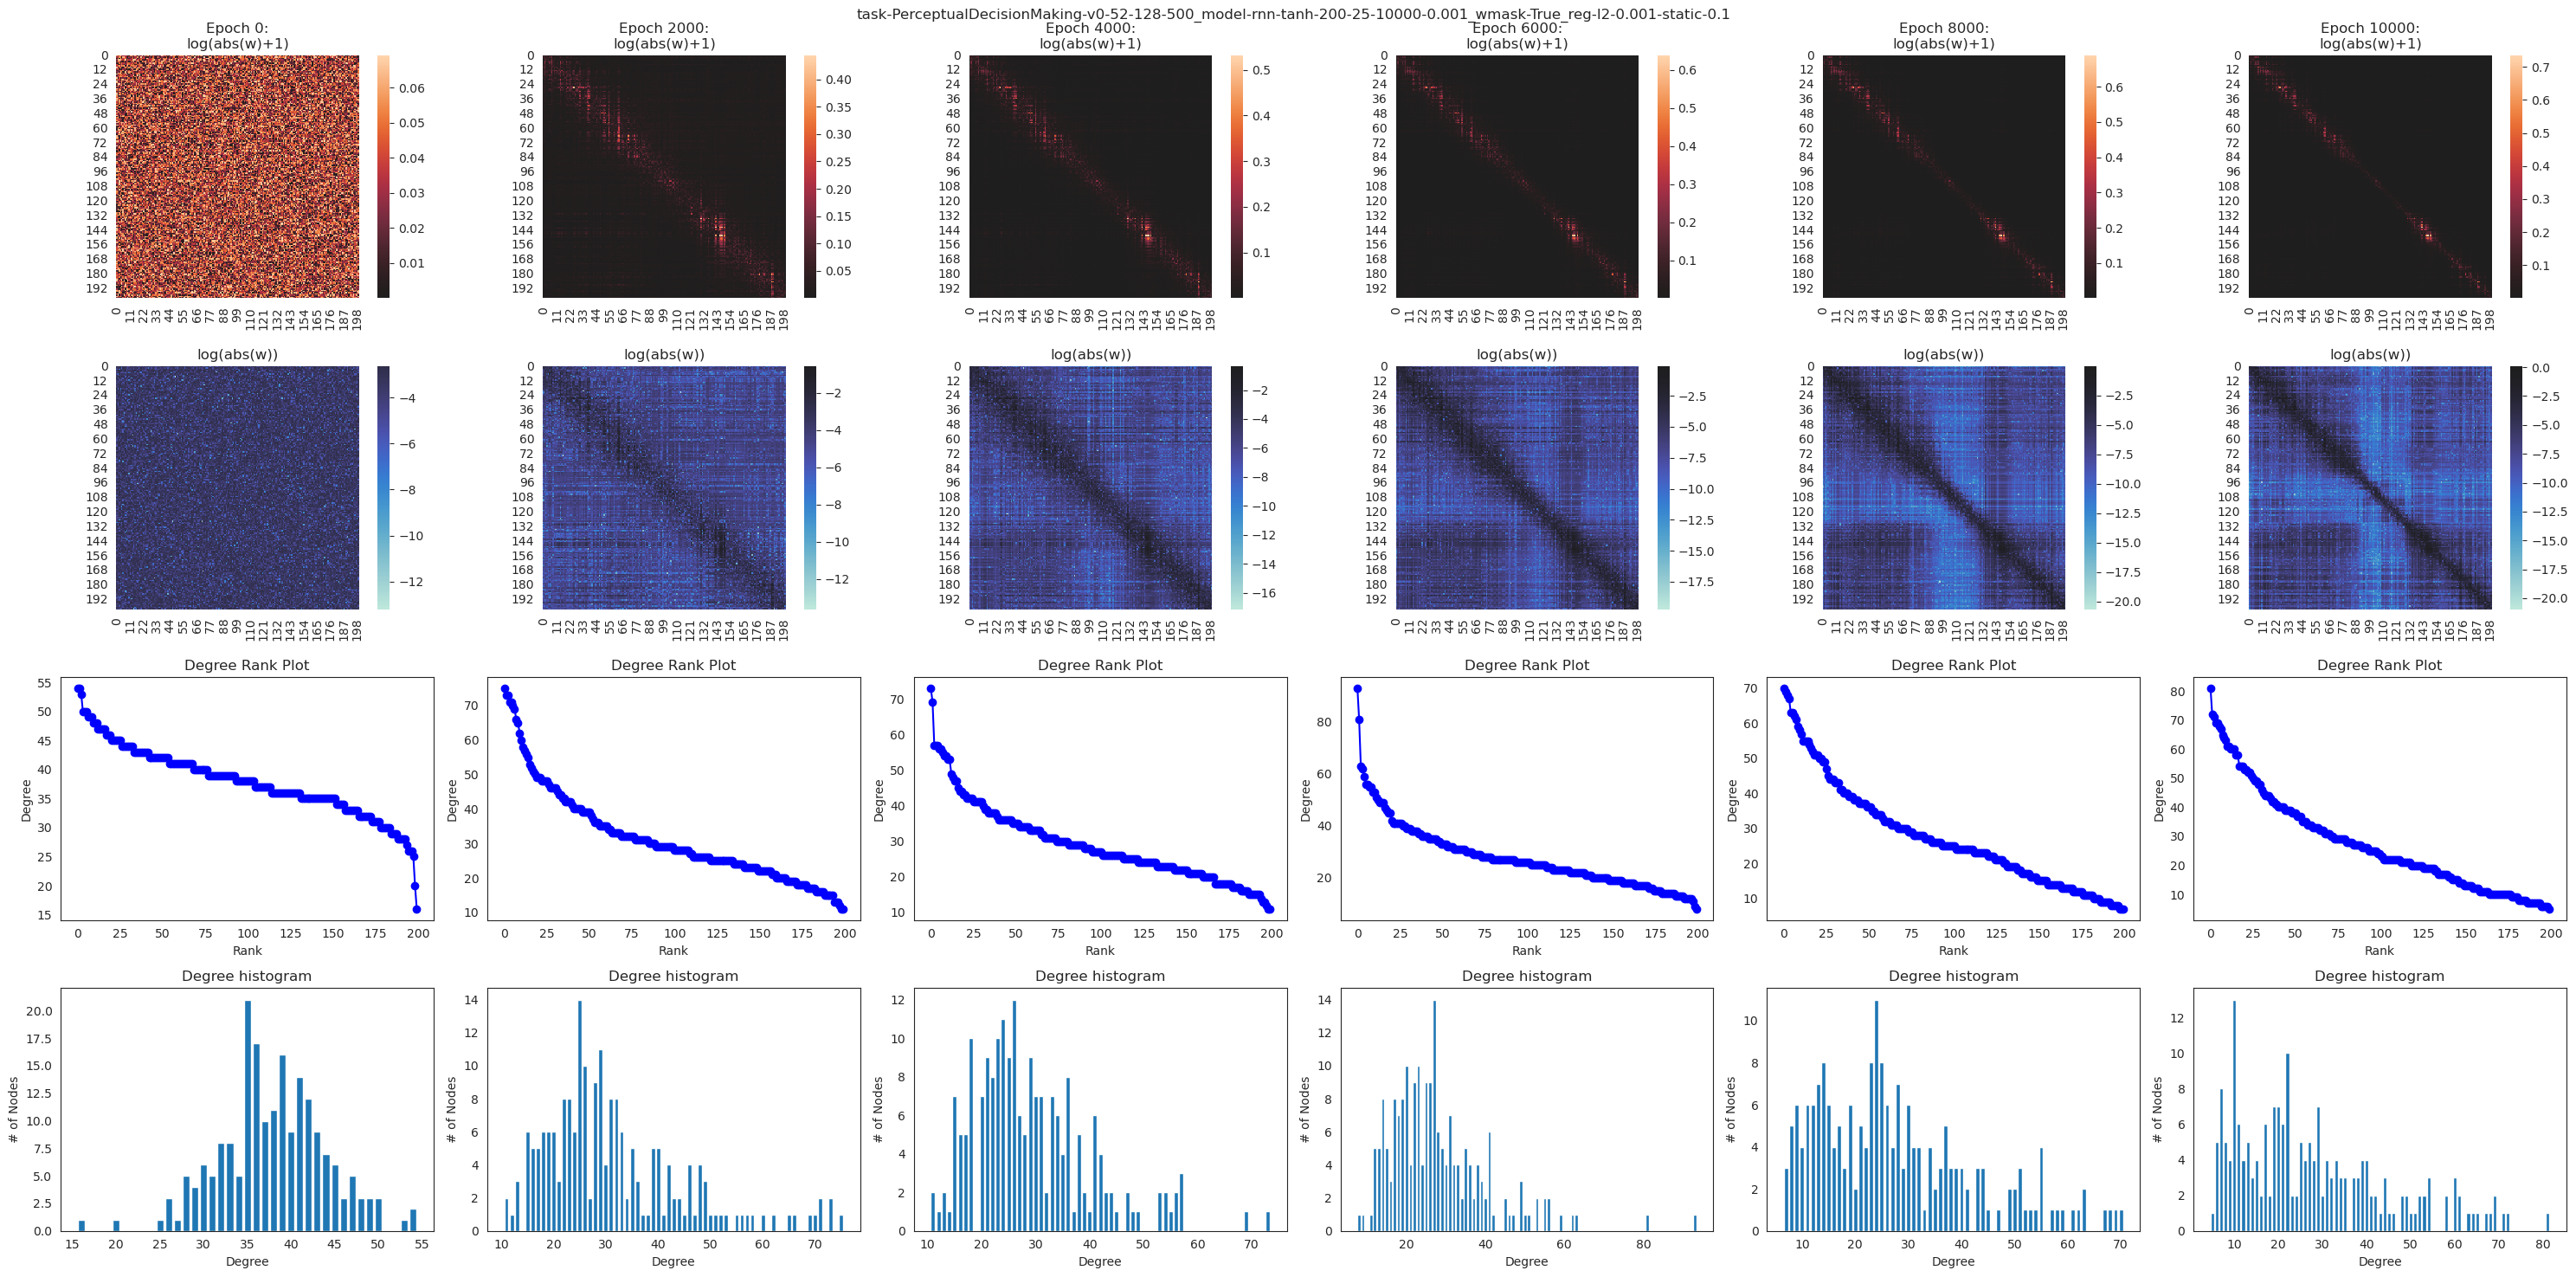

In [9]:
A = hidden_weights[0, -1].copy()
A = np.abs(A)
ci, _ = bct.algorithms.community_louvain(A, ci=None, seed=42)
ci_idx = np.argsort(ci)

indices = np.arange(0, n_logged_epochs, np.floor(n_logged_epochs/5).astype(int))
print(indices)
n_indices = len(indices)
f, ax = plt.subplots(4, n_indices, figsize=(n_indices*5, 15))
for epoch in np.arange(n_indices):
    A = hidden_weights[0, indices[epoch]].copy()
    sns.heatmap(np.log(np.abs(A)+1), ax=ax[0, epoch], square=True, center=0)
    # sns.heatmap(np.log(np.abs(A)+1)[ci_idx, :][:, ci_idx], ax=ax[0, epoch], square=True, center=0)
    ax[0, epoch].set_title('Epoch {0}:\nlog(abs(w)+1)'.format(indices[epoch]*100))

    sns.heatmap(np.log(np.abs(A)), ax=ax[1, epoch], square=True, center=0)
    # sns.heatmap(np.log(np.abs(A))[ci_idx, :][:, ci_idx], ax=ax[1, epoch], square=True, center=0)
    ax[1, epoch].set_title('log(abs(w))')

    # curve_fit(func_powerlaw, x, y, maxfev=2000 )
    A = np.abs(A)
    A = A / np.linalg.norm(A)
    thresh1 = np.quantile(A, q=0.9)
    mask = A > thresh1
    A[mask] = 1
    A[~mask] = 0
    G = nx.convert_matrix.from_numpy_array(A)
    degree_sequence = sorted((d for n, d in G.degree()), reverse=True)

    ax[2, epoch].plot(degree_sequence, "b-", marker="o")
    ax[2, epoch].set_title("Degree Rank Plot")
    ax[2, epoch].set_ylabel("Degree")
    ax[2, epoch].set_xlabel("Rank")

    ax[3, epoch].bar(*np.unique(degree_sequence, return_counts=True))
    ax[3, epoch].set_title('Degree histogram')
    ax[3, epoch].set_xlabel("Degree")
    ax[3, epoch].set_ylabel("# of Nodes")

f.suptitle(file_str)
f.tight_layout()
plt.show()

if save_figs:
    f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'weights')), dpi=300, bbox_inches='tight', pad_inches=0.01)

# Model performance vs. weights

In [10]:
mask_labels = [
    # 'input_input', 'bystanders_bystanders', 'output_output',
    'input_output', 'output_input',
    'input_bystanders', 'bystanders_input',
    'output_bystanders', 'bystanders_output'
]
n_masks = len(mask_labels)
mask_list = []
over_mask = torch.zeros((hidden_size, hidden_size), dtype=torch.bool)
for i in np.arange(n_masks):
    mask_list.append(masks[mask_labels[i]])
    over_mask += mask_list[-1]

weights = np.zeros((n_runs, n_logged_epochs, n_masks))
for run in tqdm(np.arange(n_runs)):
    for epoch in np.arange(n_logged_epochs):
        A = hidden_weights[run, epoch].copy()
        A = np.abs(A)
        # A = A / np.linalg.norm(A)

        for m, mask in enumerate(mask_list):
            weights[run, epoch, m] = np.linalg.norm(A[mask])
            # weights[run, epoch, m] = np.mean(A[mask])
        weights[run, epoch, :] = sp.stats.zscore(weights[run, epoch, :])

100%|██████████| 25/25 [00:00<00:00, 55.65it/s]


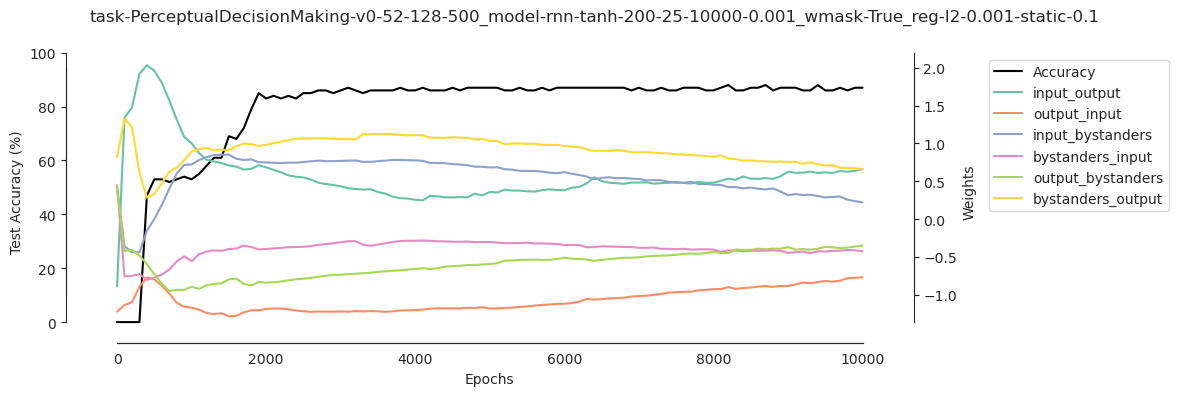

In [11]:
color_palette = sns.color_palette("Set2")

f, ax = plt.subplots(1, 1, figsize=(12, 4))
run = 0
ax.plot(np.arange(0, n_epochs+x_step, x_step), np.median(test_accuracy, axis=0)*100, color='k', label='Accuracy')
ax.set_xlabel('Epochs')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim([-2.5, 100])

ax0_twin = ax.twinx()
for m, mask in enumerate(mask_list):
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(weights[:, :, m], axis=0), color=color_palette[m], label=mask_labels[m])
ax0_twin.set_ylabel('Weights')

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax0_twin.get_legend_handles_labels()
ax0_twin.legend(lines + lines2, labels + labels2, bbox_to_anchor = (1.1, 1))

sns.despine(offset=10, trim=True, left=False, right=False, top=True, bottom=False)
f.suptitle(file_str)
f.tight_layout()
plt.show()

if save_figs:
    f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy-weights')), dpi=300, bbox_inches='tight', pad_inches=0.01)

# Model performance vs. topology

## Compute topological features

In [12]:
run_cell = True

In [13]:
if run_cell:
    base_ci = np.zeros(hidden_size)
    base_ci[masks['input_weight_mask']] = 1
    base_ci[masks['bystanders']] = 2
    base_ci[masks['output_weight_mask']] = 3
    base_ci = base_ci.astype(int)

    # for binary graphs
    modularity_undirected = np.zeros((n_runs, n_logged_epochs))
    participation_coefficient = np.zeros((n_runs, n_logged_epochs, hidden_size))
    global_efficiency_bin = np.zeros((n_runs, n_logged_epochs))

    # for weighted graphs
    # modularity_directed = np.zeros((n_runs, n_logged_epochs))
    # global_efficiency_wei = np.zeros((n_runs, n_logged_epochs))
    participation_coefficient_in = np.zeros((n_runs, n_logged_epochs, hidden_size))
    participation_coefficient_out = np.zeros((n_runs, n_logged_epochs, hidden_size))
    diffusion_efficiency = np.zeros((n_runs, n_logged_epochs))
    diffusion_efficiency_bu = np.zeros((n_runs, n_logged_epochs))
    diffusion_efficiency_td = np.zeros((n_runs, n_logged_epochs))
    diffusion_efficiency_asym = np.zeros((n_runs, n_logged_epochs))

    for run in tqdm(np.arange(n_runs)):
        for epoch in np.arange(n_logged_epochs):
            A = hidden_weights[run, epoch].copy()
            A = np.abs(A)
            A = A / np.linalg.norm(A)
            thresh1 = np.quantile(A, q=0.5)
            mask = A > thresh1
            A_bin = A.copy()
            A_bin[mask] = 1
            A_bin[~mask] = 0

            # for binary graphs
            _, modularity_undirected[run, epoch] = bct.algorithms.modularity_und(A_bin)
            # _, modularity_undirected[run, epoch] = bct.algorithms.community_louvain(A_bin, seed=42)
            participation_coefficient[run, epoch] = bct.algorithms.participation_coef(A_bin, ci=base_ci, degree='undirected')
            global_efficiency_bin[run, epoch] = bct.algorithms.efficiency_bin(A_bin)

            # for weighted graphs
            # _, modularity_directed[run, epoch] = bct.algorithms.modularity_dir(A)
            # _, modularity_directed[run, epoch] = bct.algorithms.community_louvain(A, seed=42)
            # global_efficiency_wei[run, epoch] = bct.algorithms.efficiency_wei(A)
            participation_coefficient_in[run, epoch] = bct.algorithms.participation_coef(A, ci=base_ci, degree='in')
            participation_coefficient_out[run, epoch] = bct.algorithms.participation_coef(A, ci=base_ci, degree='out')

            diffusion_efficiency[run, epoch], diff_eff = bct.algorithms.diffusion_efficiency(A)
            asymmetry = diff_eff - diff_eff.transpose()
            # diffusion_efficiency_bu[run, epoch] = np.mean(diff_eff[np.tril_indices(hidden_size, k=-1)])
            # diffusion_efficiency_td[run, epoch] = np.mean(diff_eff[np.triu_indices(hidden_size, k=1)])
            # diffusion_efficiency_asym[run, epoch] = np.mean(asymmetry[np.tril_indices(hidden_size, k=-1)])
            diffusion_efficiency_bu[run, epoch] = np.mean(diff_eff[masks['input_output']])
            diffusion_efficiency_td[run, epoch] = np.mean(diff_eff[masks['output_input']])
            diffusion_efficiency_asym[run, epoch] = np.mean(asymmetry[masks['input_output']])

100%|██████████| 25/25 [02:49<00:00,  6.79s/it]


### Modularity

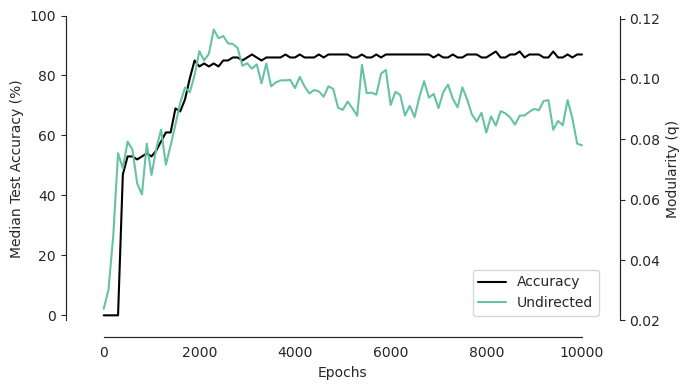

In [14]:
if run_cell:
    f, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(np.arange(0, n_epochs+x_step, x_step), np.median(test_accuracy, axis=0)*100, color='k', label='Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Median Test Accuracy (%)')
    ax.set_ylim([-2.5, 100])

    ax0_twin = ax.twinx()
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.median(modularity_directed, axis=0), color=color_palette[1], label='Directed')
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.median(modularity_undirected, axis=0), color=color_palette[0], label='Undirected')
    ax0_twin.set_ylabel('Modularity (q)')

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax0_twin.get_legend_handles_labels()
    ax0_twin.legend(lines + lines2, labels + labels2, loc='lower right')

    sns.despine(offset=10, trim=True, left=False, right=False, top=True, bottom=False)
    f.tight_layout()
    plt.show()

    if save_figs:
        f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy-modularity')), dpi=300, bbox_inches='tight', pad_inches=0.01)

### Participation coefficient

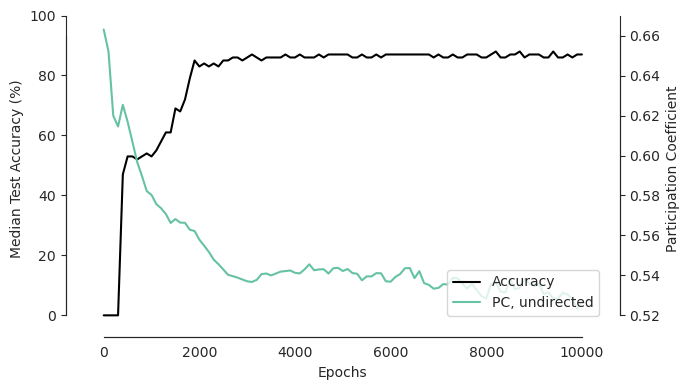

In [15]:
if run_cell:
    f, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(np.arange(0, n_epochs+x_step, x_step), np.median(test_accuracy, axis=0)*100, color='k', label='Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Median Test Accuracy (%)')
    ax.set_ylim([-2.5, 100])

    ax0_twin = ax.twinx()
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(np.mean(participation_coefficient, axis=0), axis=-1), color=color_palette[0], label='PC, undirected')
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(np.mean(participation_coefficient, axis=0)[:, masks['input_weight_mask']], axis=-1), color=color_palette[1], label='PC, undirected, input')
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(np.mean(participation_coefficient, axis=0)[:, masks['bystanders']], axis=-1), color=color_palette[2], label='PC, undirected, bystanders')
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(np.mean(participation_coefficient, axis=0)[:, masks['output_weight_mask']], axis=-1), color=color_palette[3], label='PC, undirected, output')

    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.median(np.median(participation_coefficient_in, axis=0), axis=-1), color=color_palette[1], label='PC, in')
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.median(np.median(participation_coefficient_out, axis=0), axis=-1), color=color_palette[2], label='PC, out')
    ax0_twin.set_ylabel('Participation Coefficient')

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax0_twin.get_legend_handles_labels()
    ax0_twin.legend(lines + lines2, labels + labels2, loc='lower right')

    sns.despine(offset=10, trim=True, left=False, right=False, top=True, bottom=False)
    f.tight_layout()
    plt.show()

    if save_figs:
        f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy-pcoef')), dpi=300, bbox_inches='tight', pad_inches=0.01)

### Global Efficiency

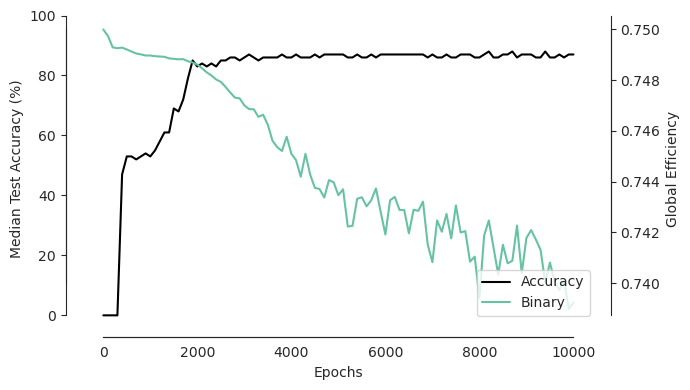

In [16]:
if run_cell:
    f, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(np.arange(0, n_epochs+x_step, x_step), np.median(test_accuracy, axis=0)*100, color='k', label='Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Median Test Accuracy (%)')
    ax.set_ylim([-2.5, 100])

    ax0_twin = ax.twinx()
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(global_efficiency_wei, axis=0), color=color_palette[0], label='Weighted')
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(global_efficiency_bin, axis=0), color=color_palette[0], label='Binary')
    ax0_twin.set_ylabel('Global Efficiency')

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax0_twin.get_legend_handles_labels()
    ax0_twin.legend(lines + lines2, labels + labels2, loc='lower right')

    sns.despine(offset=10, trim=True, left=False, right=False, top=True, bottom=False)
    f.tight_layout()
    plt.show()

    if save_figs:
        f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy-geff')), dpi=300, bbox_inches='tight', pad_inches=0.01)

### Diffusion Efficiency

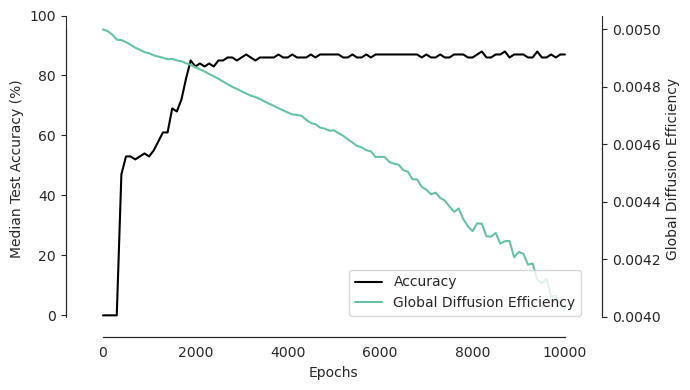

In [17]:
if run_cell:
    f, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(np.arange(0, n_epochs+x_step, x_step), np.median(test_accuracy, axis=0)*100, color='k', label='Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Median Test Accuracy (%)')
    ax.set_ylim([-2.5, 100])

    ax0_twin = ax.twinx()
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(diffusion_efficiency, axis=0), color=color_palette[0], label='Global Diffusion Efficiency')
    ax0_twin.set_ylabel('Global Diffusion Efficiency')

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax0_twin.get_legend_handles_labels()
    ax0_twin.legend(lines + lines2, labels + labels2, loc='lower right')

    sns.despine(offset=10, trim=True, left=False, right=False, top=True, bottom=False)
    f.tight_layout()
    plt.show()

    if save_figs:
        f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy-gdeff')), dpi=300, bbox_inches='tight', pad_inches=0.01)

### Diffusion Efficiency: Bottom-up and top-down

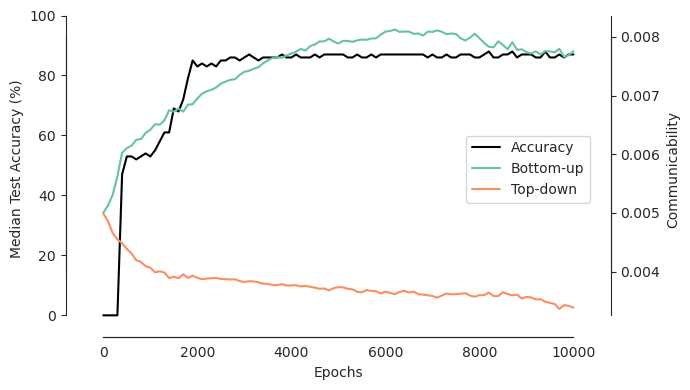

In [18]:
if run_cell:
    f, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(np.arange(0, n_epochs+x_step, x_step), np.median(test_accuracy, axis=0)*100, color='k', label='Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Median Test Accuracy (%)')
    ax.set_ylim([-2.5, 100])

    ax0_twin = ax.twinx()
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(diffusion_efficiency_bu, axis=0), color=color_palette[0], label='Bottom-up')
    ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(diffusion_efficiency_td, axis=0), color=color_palette[1], label='Top-down')
    # ax0_twin.plot(np.arange(0, n_epochs+x_step, x_step), np.mean(diffusion_efficiency_asym, axis=0), color=color_palette[2], label='Asymmetry')

    ax0_twin.set_ylabel('Communicability')

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax0_twin.get_legend_handles_labels()
    ax0_twin.legend(lines + lines2, labels + labels2, loc='center right')

    sns.despine(offset=10, trim=True, left=False, right=False, top=True, bottom=False)
    f.tight_layout()
    plt.show()

    if save_figs:
        f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'accuracy-bu_td')), dpi=300, bbox_inches='tight', pad_inches=0.01)